In [ ]:
pip install ultralytics

In [ ]:
import sys
sys.path.append('/path/to/project')

In [4]:
import pandas as pd
from ultralytics import YOLO
import helpers2

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
data_yaml_rgb = "path/to/data.yaml"
test_dataset="path/to/test"
test_images_path_rgb = test_dataset+"/images"

In [ ]:
epochs = 50
batch_size = 16
patience = 10
# save_dir_rgb='runs/detect/train'

In [ ]:
model = YOLO("yolov8n.pt")
history = model.train(data=data_yaml_rgb, epochs=epochs, batch=batch_size, imgsz=640, pretrained=True, save=True, save_period=10,
                      patience=patience,
                      # project=save_dir_rgb
                      )

In [ ]:
from google.colab import files
model_save_path = f"yolov8n_epochs{epochs}_batch{batch_size}.pt"
model.save(model_save_path)
files.download(model_save_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
def load_results_df(results_csv_path):
    return pd.read_csv(results_csv_path)
results_df_rgb  = load_results_df("runs/detect/train/results.csv")

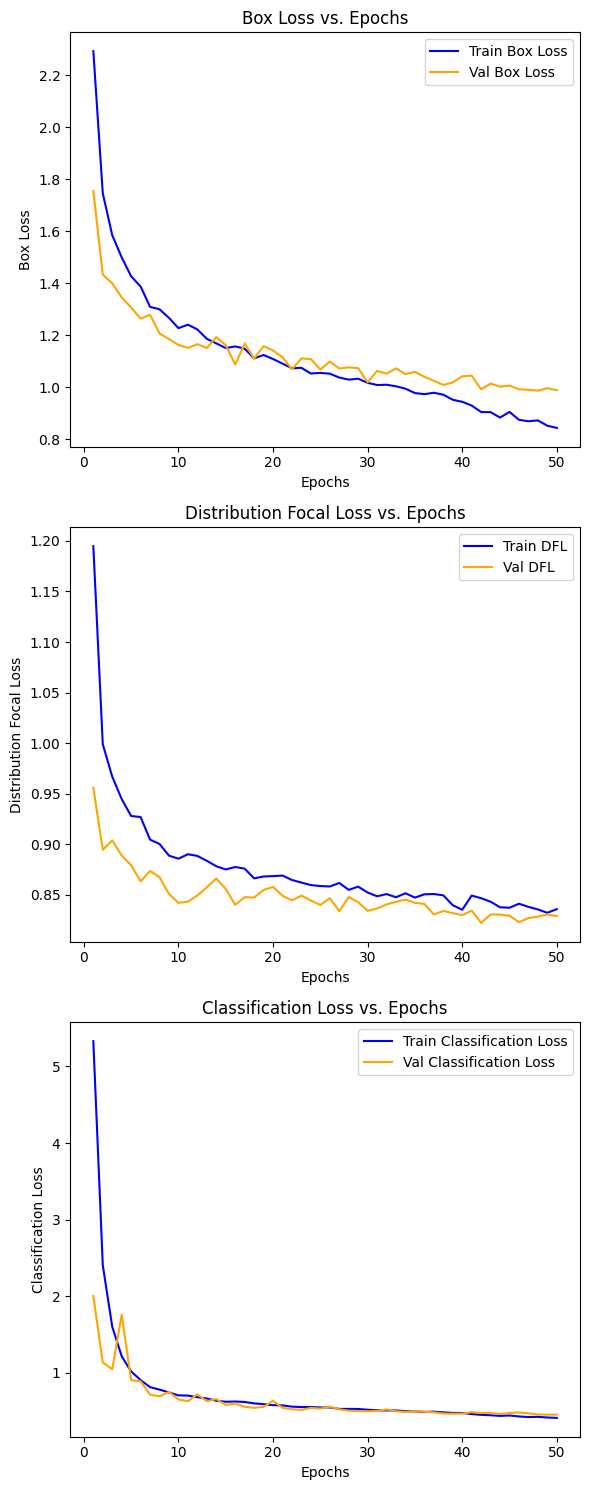

In [ ]:
helpers2.plot_losses(results_df_rgb)

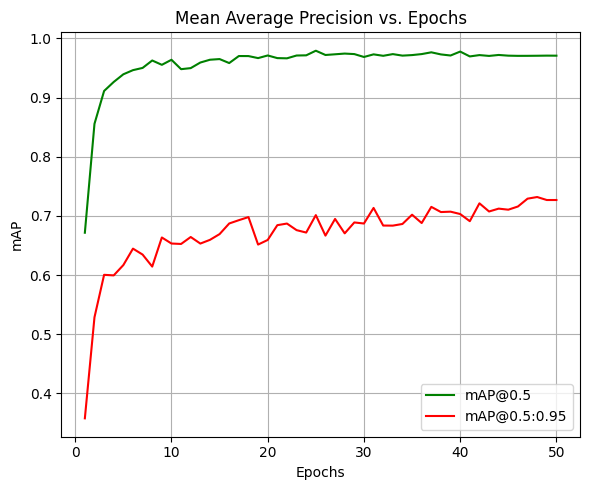

In [ ]:
helpers2.plot_map(results_df_rgb)

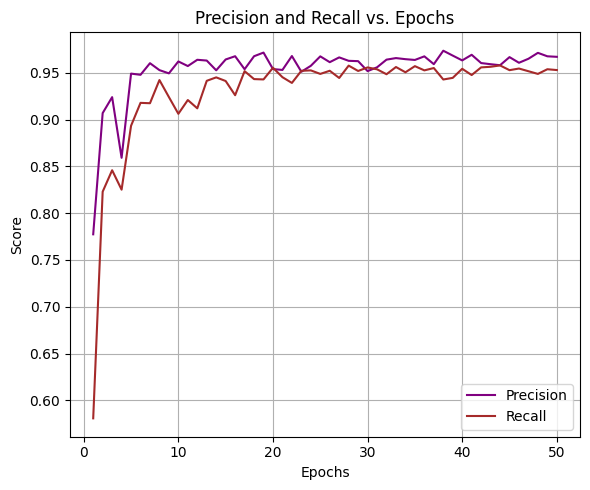

In [ ]:
helpers2.plot_precision_recall(results_df_rgb)

In [9]:
# Evaluation on the test set
metrics_rgb = model.val(data=data_yaml_rgb, split='test', imgsz=640, conf=0.25)

print(f"Mean Precision:        {metrics_rgb.box.p.mean():.4f}")
print(f"Mean Recall:           {metrics_rgb.box.r.mean():.4f}")
print(f"Mean mAP@0.5:          {metrics_rgb.box.map50.mean():.4f}")
print(f"Mean mAP@0.5:0.95:     {metrics_rgb.box.map.mean():.4f}")

Ultralytics 8.3.220 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2305.1±1405.1 MB/s, size: 446.4 KB)
val: Scanning /content/dataset/test/labels... 570 images, 63 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 570/570 1.1Kit/s 0.5s
val: New cache created: /content/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 36/36 3.1it/s 11.6s
                   all        570        988      0.979      0.976      0.984      0.758
                 other        407        453      0.912      0.949      0.969      0.707
                 PFM-1        285        299      0.997      0.977      0.986      0.713
                   PMN         90         90          1          1      0.995      0.788
                    M6         86         86      0.967       0.93      0.962      

Confusion Matrix:
[[        432           0           0           0           0           0          40]
 [          0         292           0           0           0           0           1]
 [          0           0          90           0           0           0           0]
 [          0           0           0          82           0           0           1]
 [          0           0           0           0          45           0           0]
 [          0           0           0           0           0          15           0]
 [         21           7           0           4           0           0           0]]


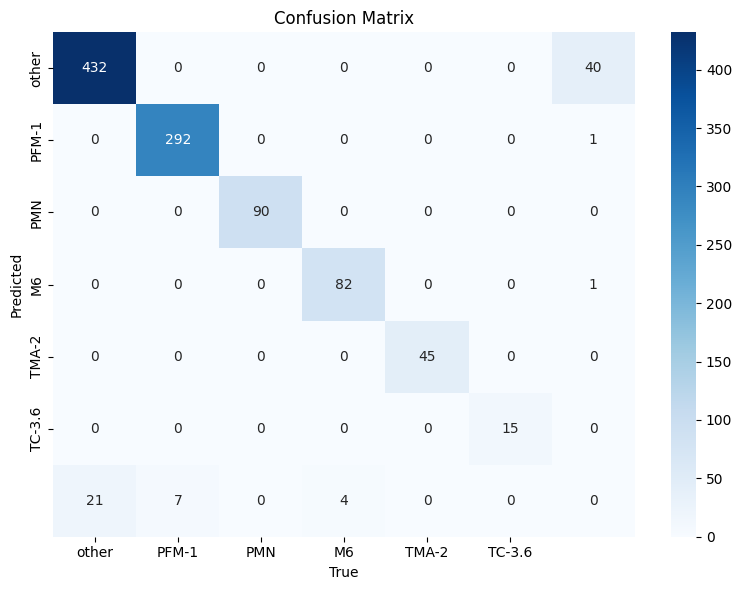

In [13]:
helpers2.plot_confusion_matrix(metrics_rgb)